In [11]:
import matplotlib.pyplot as plt
import robotic as ry
import numpy as np
import time
import os
import re
import open3d as o3d

In [12]:
from pyvirtualdisplay import Display

display = Display(visible=False, size=(1920, 1920))
display.start()

In [13]:
ry.params_clear()

ry.params_add({'Render/renderShadow': False})
ry.params_add({'Render/flatColors': True})

# This is Dog Shit code, do not read it, you may get a brain damage!

In [3]:
# loading, randomly placing and coloring the voxels. 
base = "../voxel_generation/data/"
C = ry.Config()
ids = []
p = [0, 0, .05]
for i, file in enumerate(os.listdir(base)[:5]):
    ids.append(file.split('.')[0])
    C.addFile(base+file, namePrefix = file.split('.')[0] + "_").setPosition(p)

    if np.random.rand() > .6:
        p[0] += .2
    elif np.random.rand() > .3:
        p[1] += .2
    else:
        p[2] += .2

for id in ids:
    pattern = re.compile(rf"{id}_" + "cube*")
    filtered = [x for x in C.getFrameNames() if pattern.search(x)]

    c = np.random.rand(3)
    for cube in filtered:
        C.getFrame(cube).setColor(c)

In [4]:
# calculating the maximum volume of the joing bounding box of all the voxels. This would help to align the camera
min_corner = np.array([np.inf, np.inf, np.inf])
max_corner = np.array([-np.inf, -np.inf, -np.inf])

for f in C.getFrames():
    size = f.getSize()
    if size is None or len(size) < 3:
        continue

    pos = np.array(f.getPosition())

    half = np.array(size[:3]) / 2

    min_corner = np.minimum(min_corner, pos - half)
    max_corner = np.maximum(max_corner, pos + half)

box_center = (max_corner + min_corner) / 2

In [6]:
# getting the image
def get_img(C:ry.Config, camera_view:ry.CameraView=None, cam_f:str="cam0"):
    if camera_view is None:
        camera_view = ry.CameraView(C)
    cam = C.getFrame(cam_f)
    camera_view.setCamera(cam)
    img, depth = camera_view.computeImageAndDepth(C)
    img = np.asarray(img)
    return img, depth, camera_view

In [8]:
C.view()

0

In [39]:
# aligning the camera to the center of the bounding box
C.addFrame("world").setPosition(box_center)

In [ ]:
C.addFile()

In [15]:
# getting images from different views
C = ry.Config()
C.addFile("/media/g3/mahyar/Voxel_manipulation/environment_generation/generated_envs/env_0.g")

C.delFrame("cam_dim_0")
C.delFrame("cam_dim_1")
C.delFrame("cam_dim_2")
C.delFrame("cam_dim_3")
C.delFrame("cam_dim_4")

C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')

depth_list = []
image_list = []
seg_list = []

for i in range(5):
    t = get_img(C=C, cam_f = f"cam_dim_{i}")
    image_list.append(t[0])
    depth_list.append(t[1])
    # plt.imshow(t[2].computeSegmentationID())
    # plt.show()
    
np.save(f"./image_{0}.npy", np.array(image_list))
np.save(f"./depth_{0}.npy", np.array(depth_list))
# np.save(f"./segmentation_{0}.npy", np.array(seg_list))

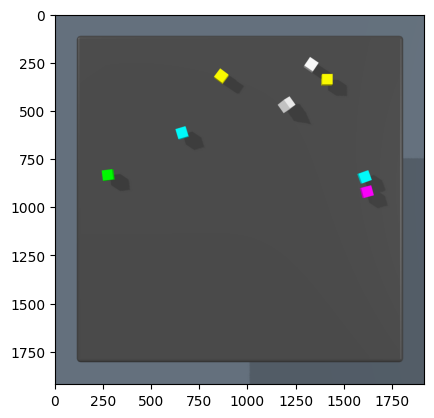

In [16]:
plt.imshow(np.load("./image_0.npy")[0])

In [34]:
t[2].getFxycxy()

array([4635.29022217, 4635.29022217,  960.        ,  960.        ])

In [17]:
C.getJointIDs()

array([], dtype=uint32)

In [43]:
C = ry.Config()
C.addFile("../voxel_generation/data/7.g")
C.view()


0

In [31]:
C.view()

37

-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!
[1207.10681152 1207.10681152  250.          250.        ]


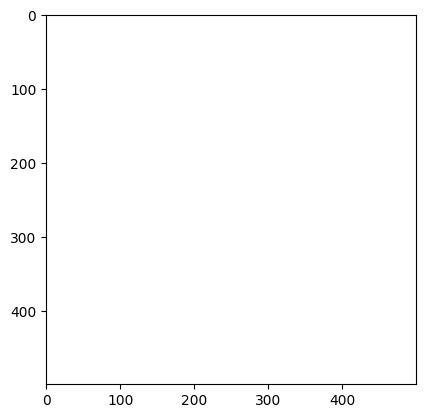

In [30]:
cam = C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:500, height:500')
t = get_img(C=C, cam_f = f"cam_dim_0")
plt.imshow(t[2].computeSegmentationImage())


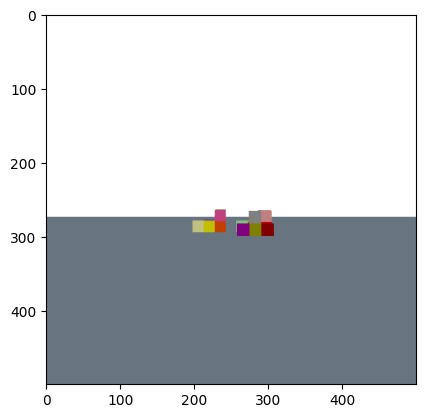

In [16]:
plt.imshow(t[2].computeSegmentationImage())

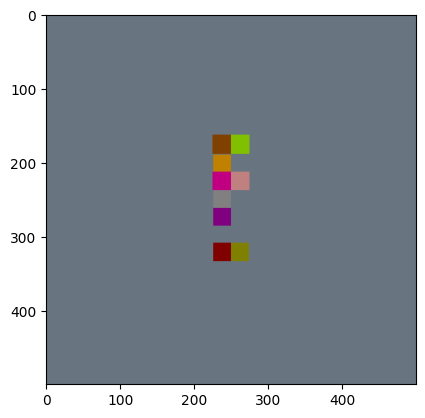

In [80]:
plt.imshow(t[2].computeSegmentationID())

In [81]:
t[2].computeSegmentationID()

array([[[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       ...,

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]]

In [10]:
# helps saving the environment
open("./highly_cluttered_env.g", "x").write(C.write())

1980

# Working on image generation

In [17]:
import sys
import os
from PandaTableVoxelClutterGenerator import PandaTableVoxelClutterGenerator
import robotic as ry

In [18]:
def get_img(C:ry.Config, camera_view:ry.CameraView=None, cam_f:str="cam0"):
    if camera_view is None:
        camera_view = ry.CameraView(C)
    cam = C.getFrame(cam_f)
    camera_view.setCamera(cam)
    img, depth = camera_view.computeImageAndDepth(C)
    img = np.asarray(img)
    return img, depth, camera_view

In [19]:
def calculate_center_of_pile(C):
    min_corner = np.array([np.inf, np.inf, np.inf])
    max_corner = np.array([-np.inf, -np.inf, -np.inf])
    
    for f in C.getFrameNames():
        size = C.getFrame(f).getSize()
        f = C.getFrame(f)
        if size is None or size.shape == () or len(size) < 3:
            continue
    
        pos = np.array(f.getPosition())
    
        half = np.array(size[:3]) / 2
    
        min_corner = np.minimum(min_corner, pos - half)
        max_corner = np.maximum(max_corner, pos + half)
    
    return (max_corner + min_corner) / 2

In [20]:
def remove_panda(C):
    for frame in C.getFrameNames():
        if "l_" in frame or "target" in frame or frame in ['cameraTop', 'cameraWrist', 'panda_collCameraWrist']:
            C.delFrame(frame)

In [21]:
def main(idx):
    # ------------------------------------------------------------
    # Create the generator
    # ------------------------------------------------------------
    generator = PandaTableVoxelClutterGenerator(
        base_scene_file=ry.raiPath("../rai-robotModels/scenarios/pandaSingle.g"),
        voxel_dir="../../voxel_generation/data/",   # folder containing voxel .g files
        output_dir="./generated_envs",
        table_frame_name="table",
        gap=0.04,
        spawn_height=0.55,
        seed=14,
        per_cube_mass=0.2,
        table_shape_size=(1.6, 1.6, 0.08, 0.02),
        panda_base_relative_pos=(0.0, 0.0, 0.05),
        marker_thickness=0.004,
        spawn_half_mode="back",   # None, "left", "right", "front", "back"
    )

    # ------------------------------------------------------------
    # Generate one environment
    # ------------------------------------------------------------
    C, summary = generator.create_environment_with_refill(
        num_voxels=int(np.random.normal(10, 4)),
        sim_seconds=10.0,
        sim_dt=0.01,
        max_refill_rounds=10,
        xy_margin=0.02,
        z_tolerance=0.15,
        batch_spawn_count=5,
        add_target_surface=True,
    )

    remove_panda(C)

    box_center = calculate_center_of_pile(C)
    
    C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
    C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
    C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
    C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
    C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')

    depth_list = []
    image_list = []
    
    for i in range(5):
        t = get_img(C=C, cam_f = f"cam_dim_{i}")
        image_list.append(t[0])
        depth_list.append(t[1])
        
    np.save(f"./image_{idx}.npy", np.array(image_list))
    np.save(f"./depth_{idx}.npy", np.array(depth_list))

    saved_path = generator.save_environment(
        C,
        file_name=f"env_{idx}.g",
    )
    # C.view()
    del C
if __name__ == "__main__":
    for idx in range(1000):
        main(idx)

FileNotFoundError: No voxel files found in: ../../voxel_generation/data

In [131]:
# C = ry.Config()
# C.addFile("./generated_envs/generated_panda_table_voxel_clutter.g") 

C.view()

0

In [152]:
!pwd

/home/mahyar/Documents/robotics/Voxel_manipulation/environment_generation/generated_envs


In [155]:
np.load("./depth_dim_0.npy").shape

(5, 1920, 1920)

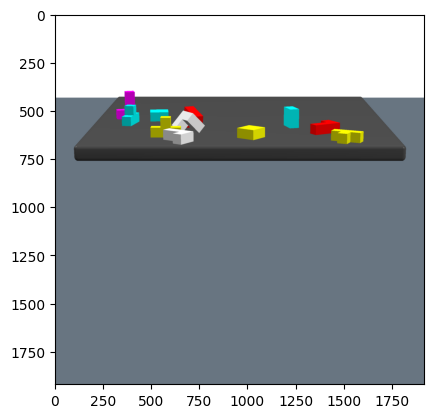

In [158]:
plt.imshow(np.load("./image_dim_0.npy")[1])

In [ ]:
def config_to_point_cloud(C: ry.Config, camera_frame: str):
    cam = ry.CameraView(C)

    cam.setCamera(C.getFrame(camera_frame))

    rgb, depth = cam.computeImageAndDepth(C)

    fxycxy = cam.getFxycxy()

    points = ry.depthImage2PointCloud(depth, fxycxy)

    h, w, _ = rgb.shape
    colors = rgb.reshape((h * w, 3))

    mask = points[:, 2] < 5
    points = points * mask
    # colors = colors * mask

    return points#, colors

C = ry.Config()
C.addFile("/home/mahyar/Documents/robotics/Voxel_manipulation/environment_generation/generated_envs/env_0.g")
cam = C.addFrame(name="cam_dim_0", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:500, height:500')

points = config_to_point_cloud(C, "cam_dim_0")
print("Point cloud size:", points.shape)

-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!
Point cloud size: (1920, 1920, 3)


In [56]:
def config_to_point_cloud(C: ry.Config, camera_frame: str):
    cam = ry.CameraView(C)
    cam.setCamera(C.getFrame(camera_frame))

    rgb, depth = cam.computeImageAndDepth(C)
    fxycxy = cam.getFxycxy()

    frame = C.getFrame(camera_frame)
    T = frame.getPosition()
    R = frame.getRotationMatrix()

    # Raw output — inspect the shape first
    points_raw = ry.depthImage2PointCloud(depth, fxycxy)
    print("points_raw shape:", points_raw.shape)   # debug — remove once confirmed

    # Flatten to (N, 3) regardless of whether output is (H, W, 3) or (N, 3)
    if points_raw.ndim == 3:
        h, w, _ = points_raw.shape
        points_cam = points_raw.reshape(-1, 3)
    else:
        points_cam = points_raw  # already (N, 3)

    h, w, _ = rgb.shape
    colors = rgb.reshape(-1, 3)   # (N, 3)

    # Now mask is 1-D of length N — safe to index both arrays
    mask = points_cam[:, 2] < 5
    points_cam = points_cam[mask]
    colors    = colors[mask]

    # Transform from camera space → world space
    points_world = (R @ points_cam.T).T + T

    return points_world, colors


def reconstruct_from_two_views(C: ry.Config, cam_frame_1: str, cam_frame_2: str):
    points1, colors1 = config_to_point_cloud(C, cam_frame_1)
    points2, colors2 = config_to_point_cloud(C, cam_frame_2)

    merged_points = np.vstack([points1, points2])
    merged_colors = np.vstack([colors1, colors2])

    return merged_points, merged_colors

In [8]:
def config_to_point_cloud(C: ry.Config, camera_frame: str):
    cam = ry.CameraView(C)
    cam.setCamera(C.getFrame(camera_frame))

    rgb, depth = cam.computeImageAndDepth(C)
    fxycxy = cam.getFxycxy()

    frame = C.getFrame(camera_frame)
    T = frame.getPosition()
    R = frame.getRotationMatrix()

    points_raw = ry.depthImage2PointCloud(depth, fxycxy)

    # Normalize to (N, 3)
    if points_raw.ndim == 3:
        points_cam = points_raw.reshape(-1, 3)
    elif points_raw.ndim == 2:
        # Handle both (N, 3) and (3, N)
        if points_raw.shape[0] == 3 and points_raw.shape[1] != 3:
            points_cam = points_raw.T   # (3, N) → (N, 3)
        else:
            points_cam = points_raw     # already (N, 3)
    else:
        raise ValueError(f"Unexpected point cloud shape: {points_raw.shape}")

    colors = rgb.reshape(-1, 3)  # (N, 3)

    # Sanity check before masking
    assert points_cam.shape[0] == colors.shape[0], \
        f"Mismatch: points {points_cam.shape} vs colors {colors.shape}"
    assert points_cam.shape[1] == 3, \
        f"points_cam should be (N,3), got {points_cam.shape}"

    mask = points_cam[:, 2] < 5
    points_cam = points_cam[mask]
    colors     = colors[mask]

    # points_cam[:, 2] *= -1   # flip Z (forward → backward)

    points_world = (R @ points_cam.T).T + T

    return points_world, colors

def reconstruct_from_two_views(C: ry.Config, cam_frame_1: str, cam_frame_2: str, cam_frame_3: str, cam_frame_4: str, cam_frame_5: str):
    """Merge point clouds from two camera viewpoints into one world-space cloud."""
    points1, colors1 = config_to_point_cloud(C, cam_frame_1)
    points2, colors2 = config_to_point_cloud(C, cam_frame_2)
    points3, colors3 = config_to_point_cloud(C, cam_frame_3)
    points4, colors4 = config_to_point_cloud(C, cam_frame_4)
    points5, colors5 = config_to_point_cloud(C, cam_frame_5)

    merged_points = np.vstack([points1, points2, points3, points4, points5])
    merged_colors = np.vstack([colors1, colors2, colors3, colors4, colors5])

    return merged_points, merged_colors

In [9]:
from pyvirtualdisplay import Display

display = Display(visible=False, size=(1920, 1920))
display.start()

C = ry.Config()

C.addFile("/media/g3/mahyar/Voxel_manipulation/environment_generation/generated_envs/env_0.g")
C.delFrame("center_box")
C.delFrame("cam_dim_0")
C.delFrame("cam_dim_1")
C.delFrame("cam_dim_2")
C.delFrame("cam_dim_3")
C.delFrame("cam_dim_4")



box_center = calculate_center_of_pile(C)
C.addFrame("center_box").setPosition(box_center)

C.addFrame(name="cam_dim_0", parent="center_box", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_1", parent="center_box", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_2", parent="center_box", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_3", parent="center_box", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_4", parent="center_box", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')


points, colors = reconstruct_from_two_views(C, "cam_dim_0", "cam_dim_1", "cam_dim_2", "cam_dim_3", "cam_dim_4")
# del C

-- WARNING:kin.cpp:getFrame:415(-1) cannot find frame named 'center_box'


In [31]:
C.getFrame("world").getSize().shape

()

In [42]:
# pts = np.concatenate(points, axis=0)
pts = points
pts[:, :2] *= -1
# pts = pts[pts[:, 2] >.6 ]

In [69]:
# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(pts)
# pcd = pcd.voxel_down_sample(.05)
# pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.0)
# o3d.visualization.draw_plotly([pcd])

In [65]:
C.view()

0

In [47]:
points

array([[-1.03552902e+00,  1.03552902e+00,  2.33650208e-05],
       [-1.03445041e+00,  1.03552902e+00,  2.33650208e-05],
       [-1.03337169e+00,  1.03552902e+00,  2.33650208e-05],
       ...,
       [-2.01683536e+00, -6.75052524e-01,  3.31797384e-04],
       [-2.01683536e+00, -6.75757885e-01,  3.31797384e-04],
       [-2.01683536e+00, -6.76463306e-01,  3.31797384e-04]],
      shape=(14283781, 3))

In [47]:
C.view()

27

In [7]:
# C.delFrame("cam_dim_0")
# C.delFrame("cam_dim_1")
# C.delFrame("cam_dim_2")
# C.delFrame("cam_dim_3")
# C.delFrame("cam_dim_4")

C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')

box_center = calculate_center_of_pile(C)

C = ry.Config()
C.addFile("/home/mahyar/Documents/robotics/Voxel_manipulation/environment_generation/generated_envs/env_0.g")

points = multi_camera_pointcloud(
    C,
    ["cam_dim_0"]#, "cam_dim_1", "cam_dim_2", "cam_dim_3", "cam_dim_4"]
)

-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_1' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_2' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_3' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_4' already exists! returning existing without modifications!


NameError: name 'multi_camera_pointcloud' is not defined

In [38]:
C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')

for cam in C.getFrames():
    if "cam" in cam.name:
        print(np.round(cam.getRelativeTransform(), 2))

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[ 1.  0.  0.  0.]
 [ 0. -1. -0.  0.]
 [ 0.  0. -1.  5.]
 [ 0.  0.  0.  1.]]
[[-1.   -0.    0.    0.  ]
 [-0.    0.26 -0.97  5.  ]
 [ 0.   -0.97 -0.26  1.5 ]
 [ 0.    0.    0.    1.  ]]
[[ 1.    0.    0.    0.  ]
 [ 0.   -0.26  0.97 -5.  ]
 [ 0.   -0.97 -0.26  1.5 ]
 [ 0.    0.    0.    1.  ]]
[[ 0.    0.26 -0.97  5.  ]
 [ 1.    0.   -0.    0.  ]
 [ 0.   -0.97 -0.26  1.5 ]
 [ 0.    0.    0.    1.  ]]
[[ 0.   -0.26  0.97 -5.  ]
 [-1.    0.   -0.    0.  ]
 [-0.   -0.97 -0.26  1.5 ]
 [ 0.    0.    0.    1.  ]]
-- WARNING:kin.cpp:addFrame:195(-1) frame already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:195(-1) frame already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:195(-1) frame already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:195(-1) frame already exists! returni

In [14]:
points = points[points[:, 2] > 0.5]